# Mini-projet - Gaz à effet de serre atmosphériques

Ce notebook étudie l'évolution dans le temps de quatre gaz mesurés par un laboratoire américain (NOAA) : le méthane (CH4), le dioxyde de carbone (CO2), le protoxyde d'azote (N2O) et l'hexafluorure de soufre (SF6).

Nous allons observer comment ces gaz augmentent dans l'atmosphère, repérer d'éventuelles variations selon les mois, puis faire des prévisions simples en comparant plusieurs méthodes (addition, multiplication, droite, courbe exponentielle).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

files = {
    'CH4': 'ch4_mm_gl.csv',
    'CO2': 'co2_mm_mlo.csv',
    'N2O': 'n2o_mm_gl.csv',
    'SF6': 'sf6_mm_gl.csv'
}

units = {
    'CH4': 'ppb (parties par milliard)',
    'CO2': 'ppm (parties par million)',
    'N2O': 'ppb (parties par milliard)',
    'SF6': 'ppt (parties par billion)'
}

dataframes = {}
dataframes_raw = {}

for gas, file in files.items():
    df_raw = pd.read_csv(file, comment='#')
    df_raw = df_raw[df_raw['average'] > 0].reset_index(drop=True)

    dataframes_raw[gas] = df_raw[['year', 'month', 'average']].copy()
    df = df_raw[['month', 'average']].copy()
    dataframes[gas] = df

    y_min, y_max = df_raw['year'].min(), df_raw['year'].max()
    m_min = int(df_raw.loc[df_raw['year'] == y_min, 'month'].iloc[0])
    m_max = int(df_raw.loc[df_raw['year'] == y_max, 'month'].iloc[-1])

    print(f"--- {gas} ---")
    print(f"Nombre d'observations : {len(df)}")
    print(f"Période étudiée : {m_min:02d}/{y_min} -> {m_max:02d}/{y_max}")
    print(f"Unité de mesure : {units[gas]}")
    print()


--- CH4 ---
Nombre d'observations : 511
Période étudiée : 07/1983 -> 01/2026
Unité de mesure : ppb (parties par milliard)

--- CO2 ---
Nombre d'observations : 818
Période étudiée : 03/1958 -> 04/2026
Unité de mesure : ppm (parties par million)

--- N2O ---
Nombre d'observations : 301
Période étudiée : 01/2001 -> 01/2026
Unité de mesure : ppb (parties par milliard)

--- SF6 ---
Nombre d'observations : 343
Période étudiée : 07/1997 -> 01/2026
Unité de mesure : ppt (parties par billion)



## Présentation des gaz étudiés

### Dioxyde de carbone (CO2) - `co2_mm_mlo.csv`
- **Rôle** : gaz principal lié aux activités humaines (transports, chauffage, industrie)
- **Unité** : ppm (parties par million) - mesure la quantité de gaz dans l'air
- **Évolution observée** : augmente régulièrement depuis les années 1960
- **Origine principale** : combustion d'énergies fossiles et déforestation

### Méthane (CH4) - `ch4_mm_gl.csv`
- **Rôle** : gaz qui retient la chaleur, émis notamment par l'agriculture et l'énergie
- **Unité** : ppb (parties par milliard)
- **Évolution observée** : hausse continue depuis les années 1980
- **Origine principale** : élevage, rizières, fuites de gaz, décharges

### Protoxyde d'azote (N2O) - `n2o_mm_gl.csv`
- **Rôle** : gaz qui retient la chaleur, en lien avec l'agriculture
- **Unité** : ppb (parties par milliard)
- **Évolution observée** : augmentation régulière depuis les années 2000
- **Origine principale** : agriculture et activités industrielles

### Hexafluorure de soufre (SF6) - `sf6_mm_gl.csv`
- **Rôle** : gaz très puissant, utilisé dans l'industrie électrique
- **Unité** : ppt (parties par billion) - quantités très faibles mais en forte hausse
- **Évolution observée** : augmentation rapide depuis les années 1990
- **Origine principale** : usage industriel (notamment l'électricité)


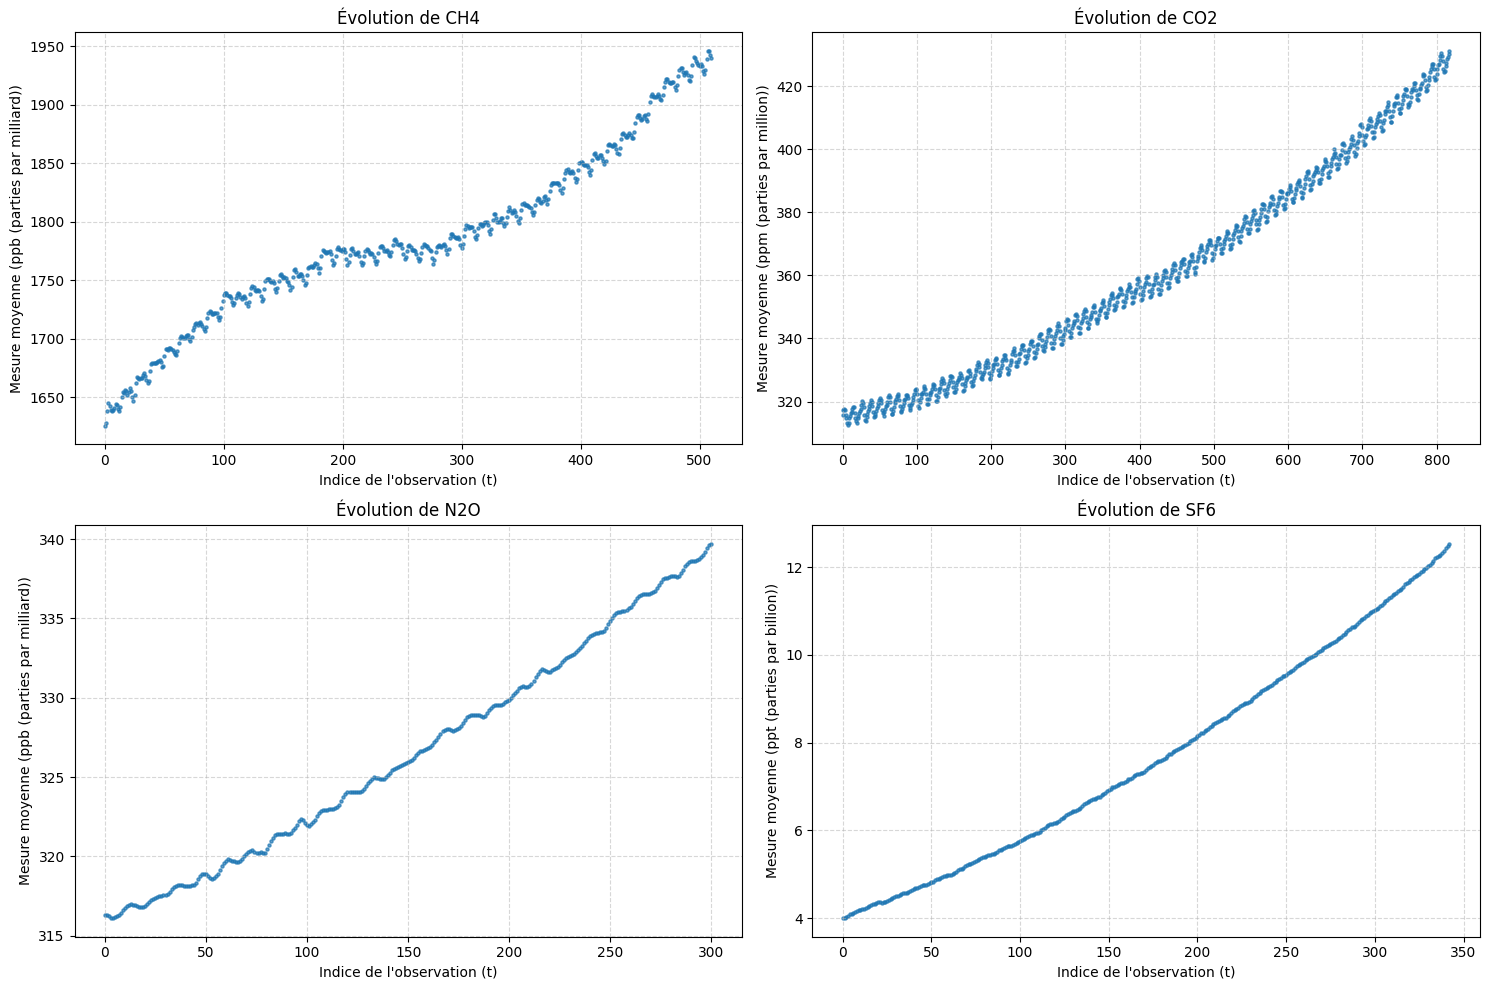

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (gas, df) in enumerate(dataframes.items()):
    axes[i].scatter(df.index, df['average'], s=5, alpha=0.7)
    axes[i].set_title(f'Évolution de {gas}')
    axes[i].set_xlabel("Indice de l'observation (t)")
    axes[i].set_ylabel(f"Mesure moyenne ({units[gas]})")
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Interprétation des nuages de points

En abscisse, l'indice $t$ représente le temps (chaque point = un mois). En ordonnée, on lit la quantité moyenne de gaz mesurée ce mois-là.

- **CO2** : la courbe **monte** avec des oscillations régulières chaque année, en forme de "dents de scie". Les variations selon les mois sont très visibles.
- **CH4** : la courbe monte aussi, avec de **légères variations selon les mois**, moins marquées que pour le CO2.
- **N2O** : hausse **régulière**, sans motif annuel net.
- **SF6** : hausse **régulière et de plus en plus rapide**, sans variation claire selon les mois.

**Conclusion** : les deux gaz dont les émissions varient clairement selon les saisons sont le **CO2** et le **CH4** (questions 5 et 6). Pour le **N2O** et le **SF6**, on utilisera directement une droite ou une courbe (questions 7 et 8).


In [3]:
MA_WEIGHTS = np.array([0.5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.5]) / 12.0

def centered_ma(series):
    return series.rolling(window=13, center=True).apply(
        lambda x: np.dot(x, MA_WEIGHTS), raw=True
    )

def future_months(last_month, n):
    return [(last_month + i - 1) % 12 + 1 for i in range(1, n + 1)]

def additive_decompose(df):
    result = df.copy()
    result['x_star'] = centered_ma(result['average'])
    result['S_t'] = result['average'] - result['x_star']
    c_j = result.groupby('month')['S_t'].mean()
    c_bar = c_j.mean()
    c_prime = c_j - c_bar
    result['c_prime'] = result['month'].map(c_prime)
    result['CVS'] = result['average'] - result['c_prime']
    clean = result.dropna(subset=['CVS'])
    model = LinearRegression()
    model.fit(clean.index.values.reshape(-1, 1), clean['CVS'].values)
    result['Trend'] = model.predict(result.index.values.reshape(-1, 1))
    return result, c_j, c_prime, model

def multiplicative_decompose(df):
    result = df.copy()
    result['x_star'] = centered_ma(result['average'])
    result['S_t'] = result['average'] / result['x_star']
    c_j = result.groupby('month')['S_t'].mean()
    c_bar = c_j.mean()
    c_prime = c_j / c_bar
    result['c_prime'] = result['month'].map(c_prime)
    result['CVS'] = result['average'] / result['c_prime']
    clean = result.dropna(subset=['CVS'])
    model = LinearRegression()
    model.fit(clean.index.values.reshape(-1, 1), clean['CVS'].values)
    result['Trend'] = model.predict(result.index.values.reshape(-1, 1))
    return result, c_j, c_prime, model

def forecast_additive(model, c_prime, last_index, last_month, n=24):
    idx = np.arange(last_index + 1, last_index + n + 1)
    months = future_months(last_month, n)
    trend = model.predict(idx.reshape(-1, 1))
    seasonal = np.array([c_prime.loc[m] for m in months])
    return idx, months, trend + seasonal

def forecast_multiplicative(model, c_prime, last_index, last_month, n=24):
    idx = np.arange(last_index + 1, last_index + n + 1)
    months = future_months(last_month, n)
    trend = model.predict(idx.reshape(-1, 1))
    seasonal = np.array([c_prime.loc[m] for m in months])
    return idx, months, trend * seasonal

def linear_regression_analysis(t, y, n_forecast=24):
    r = np.corrcoef(t, y)[0, 1]
    model = LinearRegression()
    model.fit(t.reshape(-1, 1), y)
    a, b = model.coef_[0], model.intercept_
    last_t = t[-1]
    future_t = np.arange(last_t + 1, last_t + n_forecast + 1)
    forecast = model.predict(future_t.reshape(-1, 1))
    return r, a, b, model, future_t, forecast

def exp_regression_analysis(t, y, n_forecast=24):
    log_y = np.log(y)
    r_log = np.corrcoef(t, log_y)[0, 1]
    model = LinearRegression()
    model.fit(t.reshape(-1, 1), log_y)
    B = model.coef_[0]
    A = np.exp(model.intercept_)
    last_t = t[-1]
    future_t = np.arange(last_t + 1, last_t + n_forecast + 1)
    forecast = A * np.exp(B * future_t)
    y_hat = A * np.exp(B * t)
    rmse_lin = np.sqrt(np.mean((y - LinearRegression().fit(t.reshape(-1,1), y).predict(t.reshape(-1,1)))**2))
    rmse_exp = np.sqrt(np.mean((y - y_hat)**2))
    return r_log, A, B, future_t, forecast, rmse_lin, rmse_exp, y_hat

def annual_aggregate(df_raw):
    return df_raw.groupby('year', as_index=False)['average'].mean()

def plot_additive_decomposition(df, gas, unit):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(df.index, df['average'], alpha=0.6, label='$x_t$')
    axes[0, 0].plot(df.index, df['x_star'], color='orange', label='$x^*_t$ (série lissée)')
    axes[0, 0].set_title('Série initiale et moyenne mobile centrée')
    axes[0, 0].set_xlabel('t'); axes[0, 0].set_ylabel(unit)
    axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(df.index, df['S_t'], color='purple', alpha=0.7)
    axes[0, 1].set_title('$S_t = x_t - x^*_t$ (résidu saisonnier)')
    axes[0, 1].set_xlabel('t'); axes[0, 1].grid(alpha=0.3)

    axes[1, 0].plot(df.index, df['CVS'], color='green', label='CVS')
    axes[1, 0].plot(df.index, df['Trend'], color='red', linewidth=2, label='Tendance')
    axes[1, 0].set_title('Série CVS et tendance linéaire')
    axes[1, 0].set_xlabel('t'); axes[1, 0].set_ylabel(unit)
    axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(df.index, df['average'], alpha=0.4, label='Série initiale')
    axes[1, 1].plot(df.index, df['CVS'], color='green', alpha=0.7, label='CVS')
    axes[1, 1].plot(df.index, df['Trend'], color='red', linewidth=2, label='Tendance')
    axes[1, 1].set_title(f"Vue d'ensemble - {gas}")
    axes[1, 1].set_xlabel('t'); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_additive_forecast(df, gas, unit, model, c_prime, last_index, last_month):
    f_idx, f_months, f_vals = forecast_additive(model, c_prime, last_index, last_month)
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df['average'], alpha=0.4, label='Observations')
    plt.plot(df.index, df['Trend'], color='red', label='Tendance')
    plt.plot(f_idx, f_vals, '--', color='darkred', linewidth=2, label='Prévisions (24 mois)')
    plt.title(f'Prévisions additives - {gas}')
    plt.xlabel('t'); plt.ylabel(unit); plt.legend(); plt.grid(alpha=0.3)
    plt.show()
    return f_idx, f_vals

def plot_multiplicative_decomposition(df, gas, unit):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(df.index, df['average'], alpha=0.6, label='$X_t$')
    axes[0, 0].plot(df.index, df['x_star'], color='orange', label='$X^*_t$')
    axes[0, 0].set_title('Série initiale et série lissée')
    axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(df.index, df['S_t'], color='purple', alpha=0.7)
    axes[0, 1].set_title('$S_t = X_t / X^*_t$')
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].plot(df.index, df['CVS'], color='green', label='CVS')
    axes[1, 0].plot(df.index, df['Trend'], color='red', linewidth=2, label='Tendance')
    axes[1, 0].set_title('Série CVS et tendance')
    axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(df.index, df['average'], alpha=0.4, label='Initiale')
    axes[1, 1].plot(df.index, df['CVS'], color='green', alpha=0.7, label='CVS')
    axes[1, 1].plot(df.index, df['Trend'], color='red', linewidth=2, label='Tendance')
    axes[1, 1].set_title(f"Vue d'ensemble multiplicative - {gas}")
    axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_multiplicative_forecast(df, gas, unit, model, c_prime, last_index, last_month):
    f_idx, f_months, f_vals = forecast_multiplicative(model, c_prime, last_index, last_month)
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df['average'], alpha=0.4, label='Observations')
    plt.plot(df.index, df['Trend'], color='red', label='Tendance')
    plt.plot(f_idx, f_vals, '--', color='darkred', linewidth=2, label='Prévisions (24 mois)')
    plt.title(f'Prévisions multiplicatives - {gas}')
    plt.xlabel('t'); plt.ylabel(unit); plt.legend(); plt.grid(alpha=0.3)
    plt.show()


## Question 5 - Décomposition additive : CO2

On cherche à écrire $x_t = \text{tendance} + \text{saisonnalité}$.

La moyenne mobile centrée d'ordre 12 est définie par :
$$x^*_t = \frac{1}{12}\left(\frac{1}{2}x_{t-6} + x_{t-5} + \cdots + x_{t+5} + \frac{1}{2}x_{t+6}\right)$$

Cette quantité n'est **pas calculable** pour les **6 premiers et 6 derniers mois** de la série : la fenêtre $[t-6, t+6]$ déborde alors des limites des données disponibles.


Mois sans moyenne mobile calculable : 12 (6 en début + 6 en fin de série)

Coefficients mensuels corrigés c'_j (additif) :
month
1     0.0812
2     0.7277
3     1.4342
4     2.5878
5     3.0371
6     2.3353
7     0.6576
8    -1.5238
9    -3.1755
10   -3.2515
11   -2.0487
12   -0.8614
Name: S_t, dtype: float64


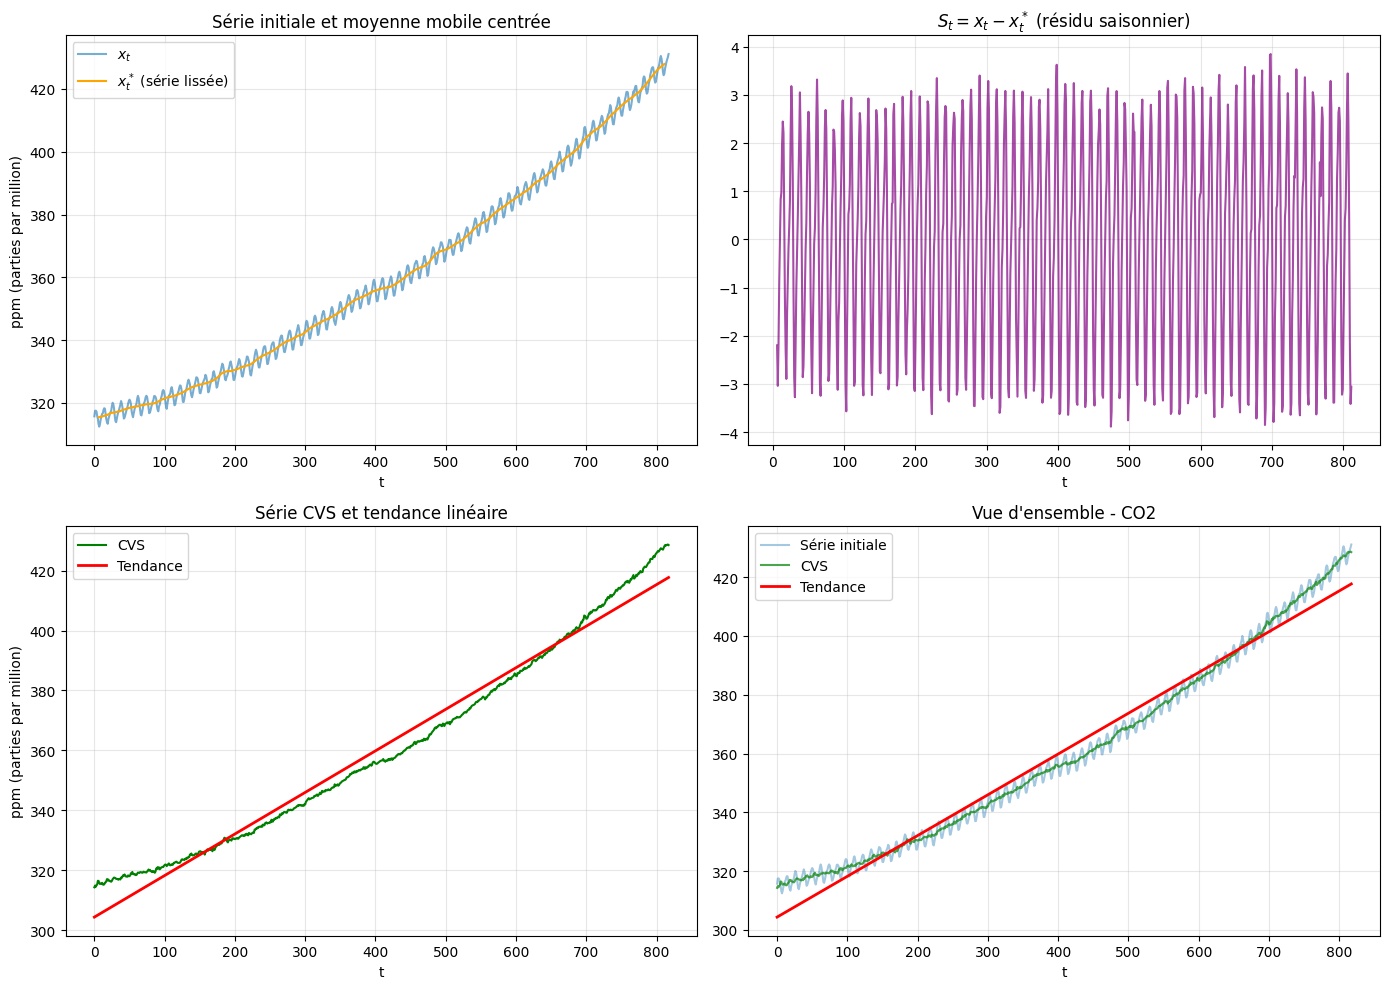

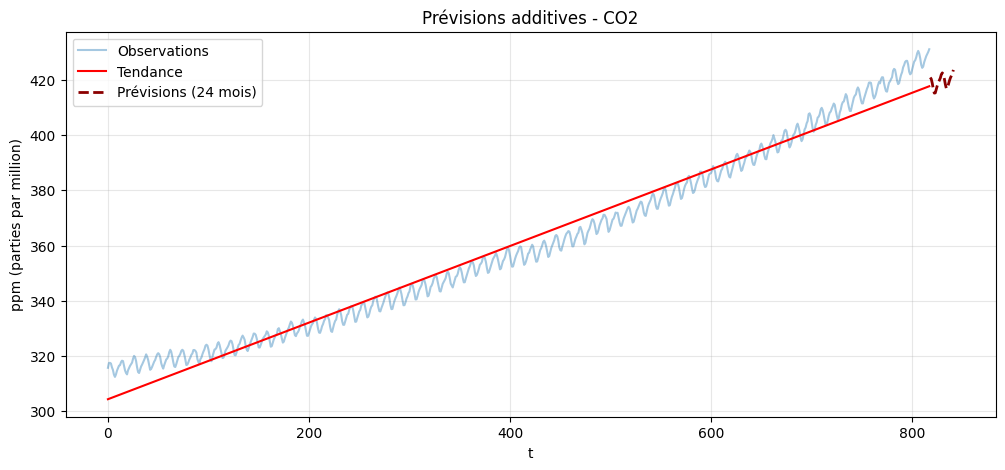


Équation de la tendance : CVS(t) = 0.138770*t + 304.3316


In [4]:
gas = 'CO2'
df_co2_add, c_j_co2, c_prime_co2, model_co2_add = additive_decompose(dataframes[gas].copy())

nan_ma = df_co2_add['x_star'].isna().sum()
print(f"Mois sans moyenne mobile calculable : {nan_ma} (6 en début + 6 en fin de série)")
print("\nCoefficients mensuels corrigés c'_j (additif) :")
print(c_prime_co2.round(4))

plot_additive_decomposition(df_co2_add, gas, units[gas])
f_idx_co2, f_vals_co2 = plot_additive_forecast(
    df_co2_add, gas, units[gas], model_co2_add, c_prime_co2,
    df_co2_add.index[-1], df_co2_add['month'].iloc[-1]
)
a, b = model_co2_add.coef_[0], model_co2_add.intercept_
print(f"\nÉquation de la tendance : CVS(t) = {a:.6f}*t + {b:.4f}")


### Interprétation - CO2 (modèle additif)

- **$x^*_t$ (série lissée)** : moyenne calculée sur 13 mois autour de $t$. Elle "enlève" les pics et creux annuels pour faire apparaître la tendance générale. On parle de série lissée car les variations rapides sont atténuées.
- **$S_t = x_t - x^*_t$** : différence entre la mesure réelle et la tendance lissée. Elle montre surtout l'effet du mois.
- **$c_j$** : effet moyen de chaque mois $j$ (moyenne des $S_t$ de ce mois). Pour le CO2, certains mois sont au-dessus de la tendance, d'autres en dessous.
- **$c'_j = c_j - \bar{c}$** : coefficients corrigés pour que leur moyenne sur l'année soit nulle.
- **CVS** : données corrigées de l'effet des mois, $x_t - c'_j$. La droite tracée sur la CVS montre l'augmentation globale du CO2 dans le temps.
- **Prévisions** : pour un mois futur, $\hat{x}_t = \text{tendance}(t) + c'_j$. On prolonge la droite et on ajoute l'effet du mois, en supposant que le passé se répète.


## Question 5 - Décomposition additive : CH4


Coefficients mensuels corrigés c'_j (additif) :
month
1     2.1560
2     1.0787
3     1.2670
4     1.1770
5    -1.0006
6    -5.4767
7    -8.7679
8    -6.0811
9     0.6312
10    5.0571
11    5.6686
12    4.2906
Name: S_t, dtype: float64


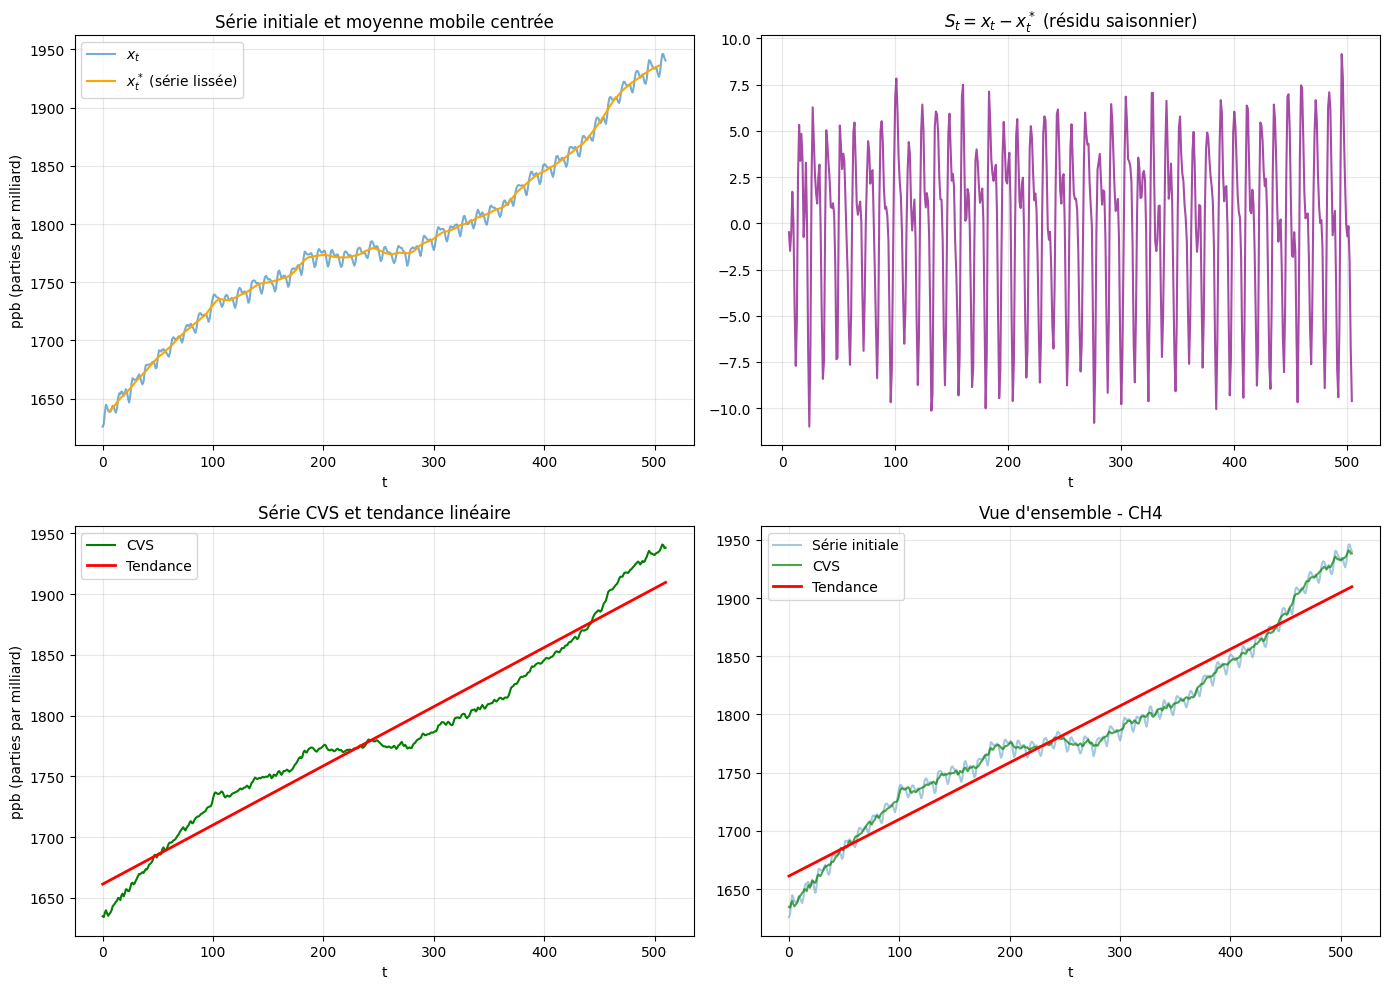

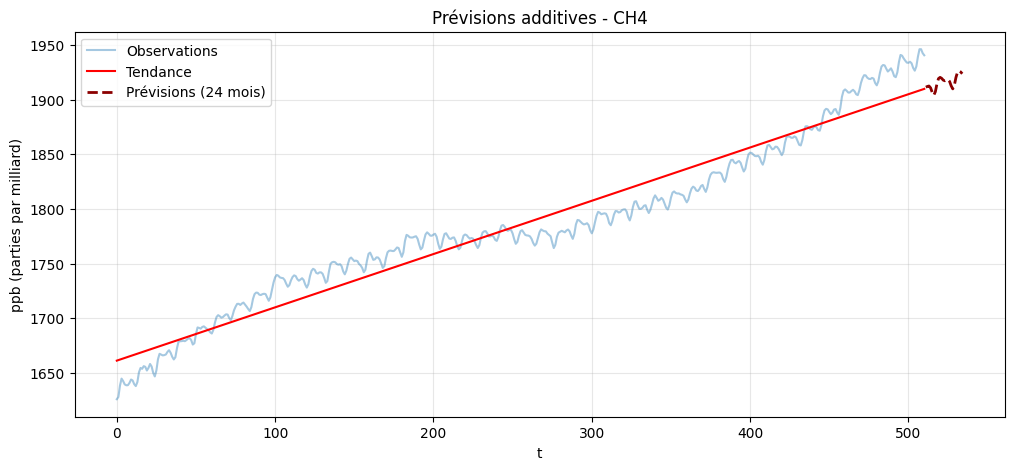


Équation de la tendance : CVS(t) = 0.487142*t + 1661.2640


In [5]:
gas = 'CH4'
df_ch4_add, c_j_ch4, c_prime_ch4, model_ch4_add = additive_decompose(dataframes[gas].copy())

print("Coefficients mensuels corrigés c'_j (additif) :")
print(c_prime_ch4.round(4))

plot_additive_decomposition(df_ch4_add, gas, units[gas])
plot_additive_forecast(
    df_ch4_add, gas, units[gas], model_ch4_add, c_prime_ch4,
    df_ch4_add.index[-1], df_ch4_add['month'].iloc[-1]
)
a, b = model_ch4_add.coef_[0], model_ch4_add.intercept_
print(f"\nÉquation de la tendance : CVS(t) = {a:.6f}*t + {b:.4f}")


### Interprétation - CH4 (modèle additif)

Le CH4 varie moins selon les mois que le CO2 : les coefficients $c'_j$ sont plus petits. La droite de tendance montre une hausse continue dans le temps. Pour prévoir un mois futur, on prolonge cette droite et on ajoute l'effet moyen du mois concerné.

### À quoi peuvent être dues les variations saisonnières ?

- **CO2** : en été, il y a davantage de végétation dans l'hémisphère nord, ce qui "absorbe" une partie du CO2 ; en hiver, l'effet est inverse. Les saisons expliquent donc les oscillations observées.
- **CH4** : les quantités mesurées varient un peu selon les saisons, par exemple à cause des conditions météo et des activités humaines qui changent au cours de l'année.


## Question 6 - Décomposition multiplicative : CO2

On cherche maintenant à écrire $x_t = \text{tendance} \times \text{saisonnalité}$.

Les étapes sont analogues, mais les opérations deviennent multiplicatives :
- $S_t = X_t / X^*_t$
- $c'_j = c_j / \bar{c}$
- CVS $= X_t / c'_j$
- Prévision $= \text{tendance}(t) \times c'_j$


Coefficients mensuels corrigés c'_j (multiplicatif) :
month
1     1.000193
2     1.001998
3     1.003988
4     1.007192
5     1.008447
6     1.006506
7     1.001880
8     0.995821
9     0.991188
10    0.990946
11    0.994269
12    0.997571
Name: S_t, dtype: float64


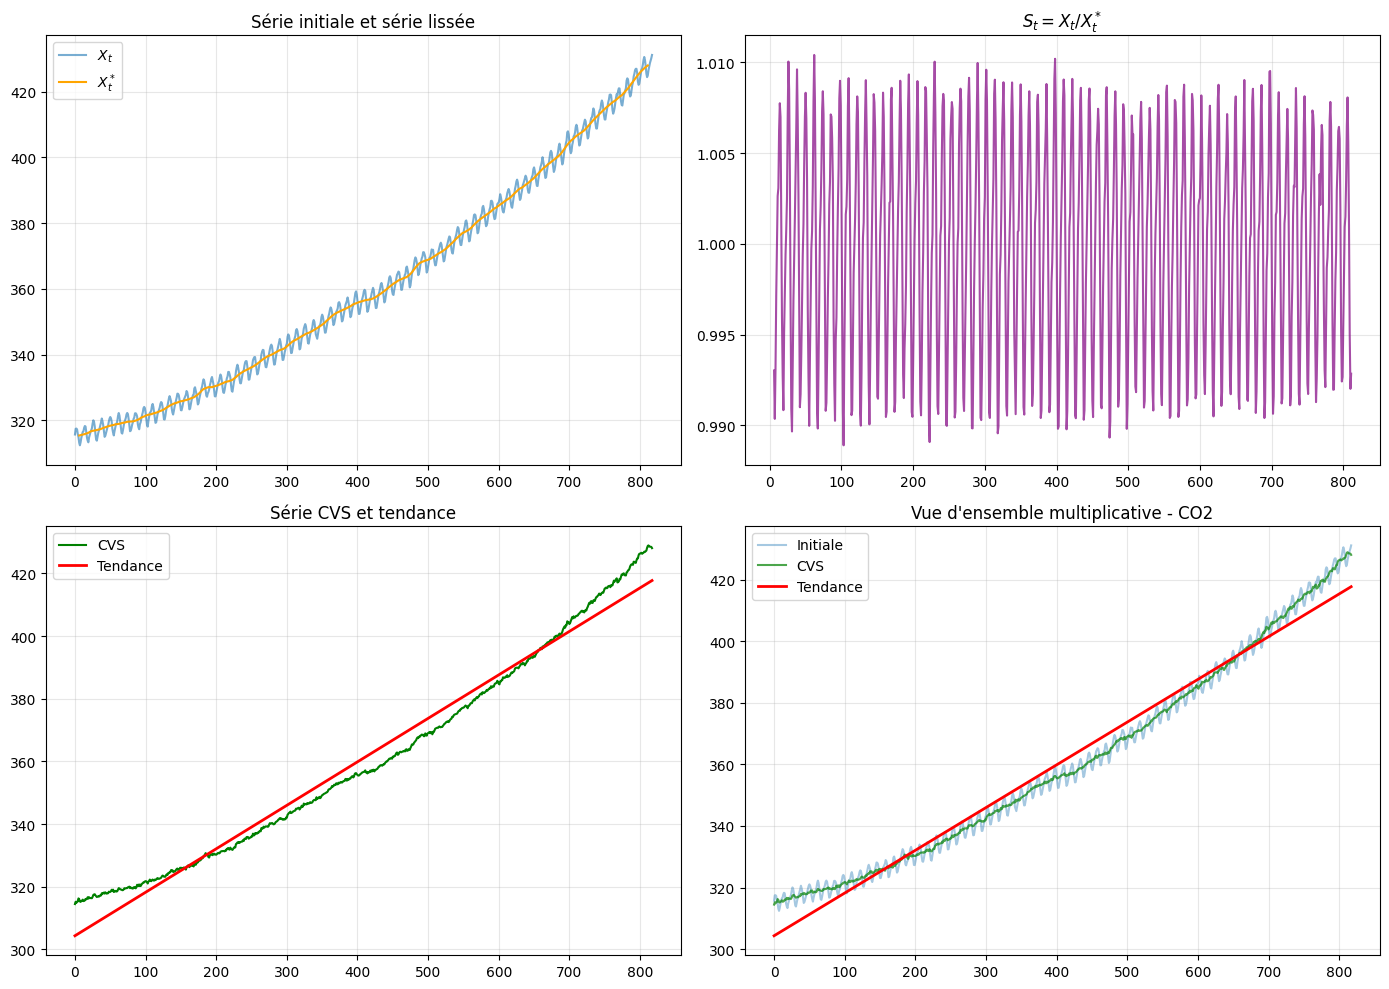

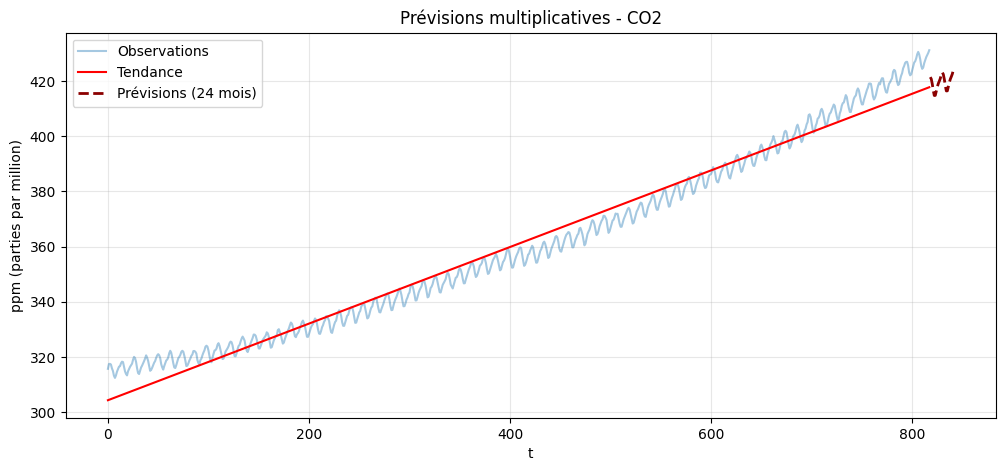

In [6]:
gas = 'CO2'
df_co2_mul, c_j_co2_m, c_prime_co2_m, model_co2_mul = multiplicative_decompose(dataframes[gas].copy())

print("Coefficients mensuels corrigés c'_j (multiplicatif) :")
print(c_prime_co2_m.round(6))

plot_multiplicative_decomposition(df_co2_mul, gas, units[gas])
plot_multiplicative_forecast(
    df_co2_mul, gas, units[gas], model_co2_mul, c_prime_co2_m,
    df_co2_mul.index[-1], df_co2_mul['month'].iloc[-1]
)


## Question 6 - Décomposition multiplicative : CH4


Coefficients mensuels corrigés c'_j (multiplicatif) :
month
1     1.001211
2     1.000610
3     1.000718
4     1.000668
5     0.999449
6     0.996941
7     0.995090
8     0.996579
9     1.000345
10    1.002825
11    1.003164
12    1.002399
Name: S_t, dtype: float64


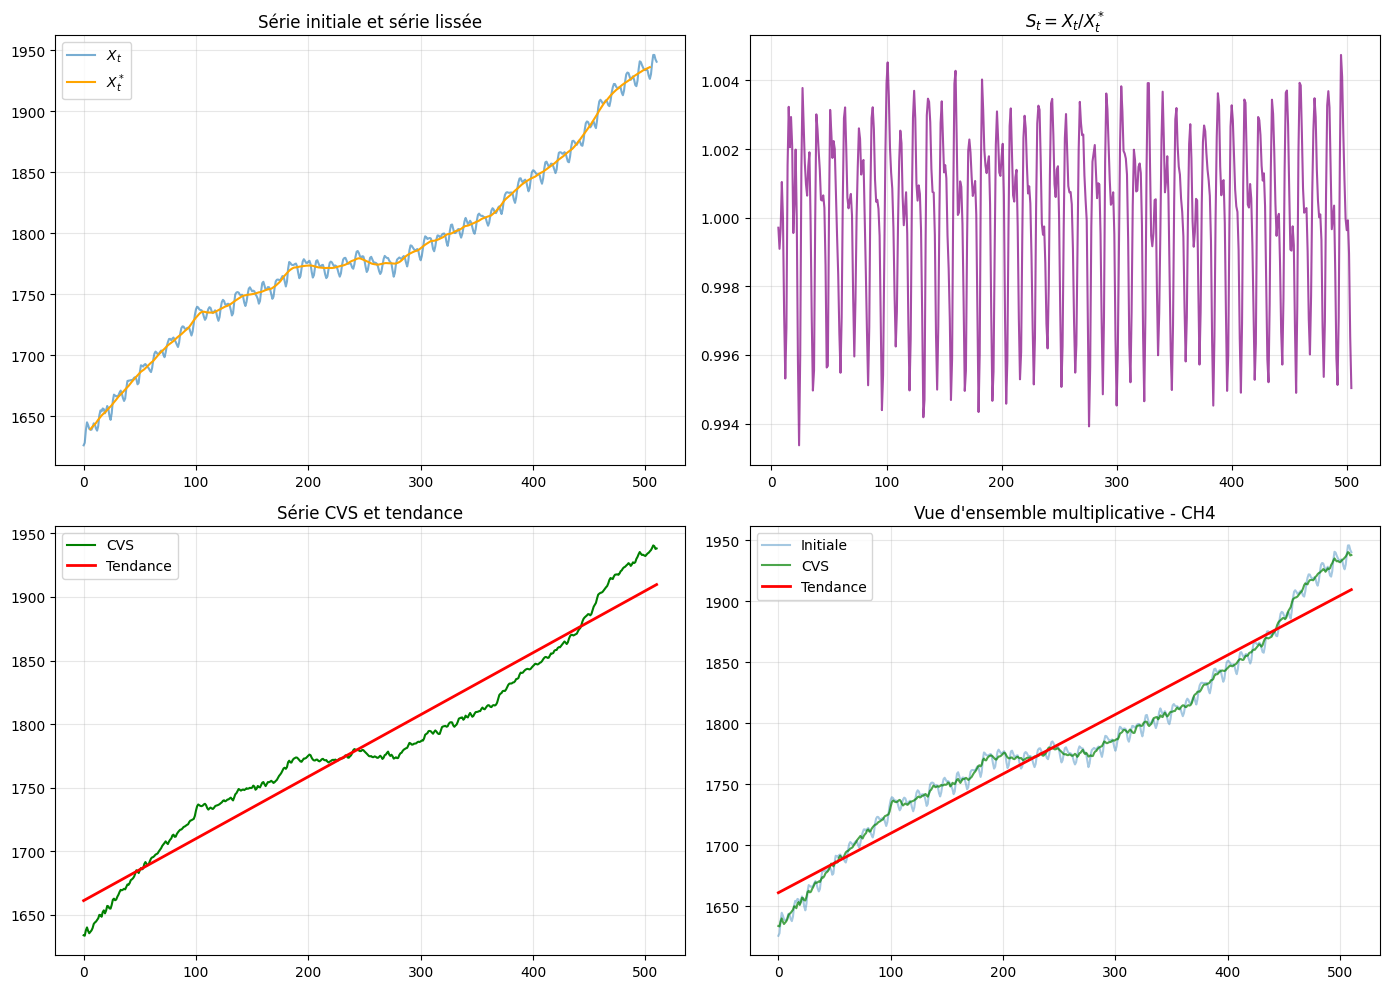

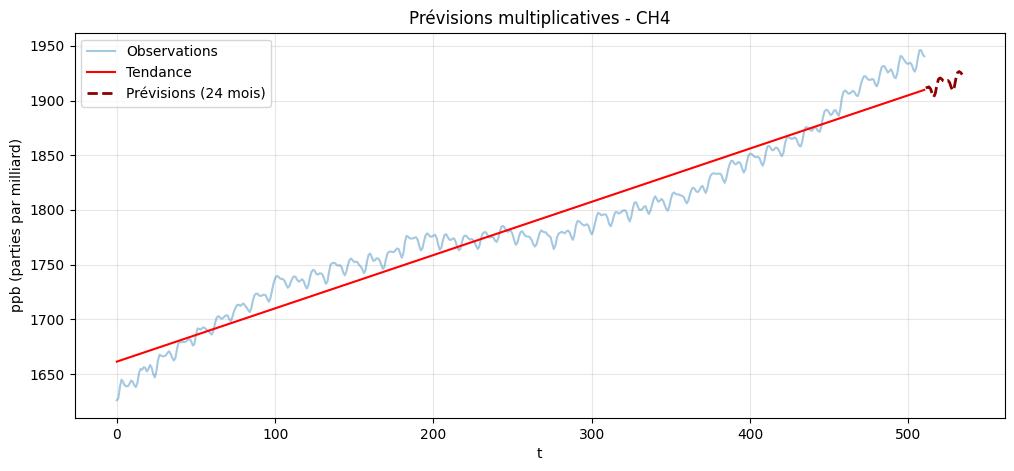

In [7]:
gas = 'CH4'
df_ch4_mul, c_j_ch4_m, c_prime_ch4_m, model_ch4_mul = multiplicative_decompose(dataframes[gas].copy())

print("Coefficients mensuels corrigés c'_j (multiplicatif) :")
print(c_prime_ch4_m.round(6))

plot_multiplicative_decomposition(df_ch4_mul, gas, units[gas])
plot_multiplicative_forecast(
    df_ch4_mul, gas, units[gas], model_ch4_mul, c_prime_ch4_m,
    df_ch4_mul.index[-1], df_ch4_mul['month'].iloc[-1]
)


### Comparaison des modèles additif (Q5) et multiplicatif (Q6)

**Modèle additif** : on **ajoute** un effet lié au mois à la tendance. Les coefficients corrigés s'écrivent $c'_j = c_j - \bar{c}$ et la prévision est : tendance + effet du mois.

**Modèle multiplicatif** : on **multiplie** la tendance par un facteur qui dépend du mois. Les coefficients corrigés s'écrivent $c'_j = c_j / \bar{c}$ et la prévision est : tendance × effet du mois.

Pour le **CO2**, les écarts selon les mois grandissent un peu avec le temps, ce qui rapprocherait le multiplicatif. Mais le modèle **additif** reste plus simple à comprendre et donne de bonnes prévisions sur deux ans.

Pour le **CH4**, les variations selon les mois sont faibles : les deux modèles donnent des résultats proches.

**Conclusion** : le modèle **additif** nous semble le plus pertinent ici, car il est plus simple et suffisant pour nos données.


## Question 7 - Régression linéaire : N2O

Pour les gaz sans variation marquée selon les mois, on cherche une droite qui relie le temps $t$ et la mesure $x_t$.


Coefficient de corrélation r = 0.996568
Équation : x_t = 0.079146*t + 314.7161


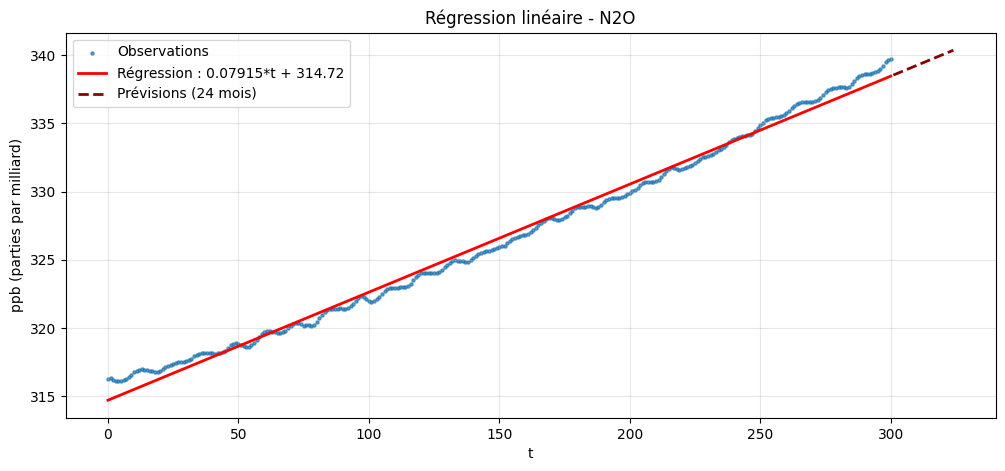

In [8]:
gas = 'N2O'
df = dataframes[gas]
t = df.index.values.astype(float)
y = df['average'].values

r, a, b, model_lin, future_t, forecast_lin = linear_regression_analysis(t, y)

print(f"Coefficient de corrélation r = {r:.6f}")
print(f"Équation : x_t = {a:.6f}*t + {b:.4f}")

plt.figure(figsize=(12, 5))
plt.scatter(t, y, s=5, alpha=0.7, label='Observations')
plt.plot(t, model_lin.predict(t.reshape(-1, 1)), color='red', linewidth=2,
         label=f'Régression : {a:.5f}*t + {b:.2f}')
plt.plot(future_t, forecast_lin, '--', color='darkred', linewidth=2, label='Prévisions (24 mois)')
plt.title(f'Régression linéaire - {gas}')
plt.xlabel('t'); plt.ylabel(units[gas]); plt.legend(); plt.grid(alpha=0.3)
plt.show()


### Interprétation - N2O (régression linéaire)

Le coefficient de corrélation est très proche de 1 : quand le temps avance, la quantité de N2O augmente de façon très régulière. La droite a une pente positive, ce qui confirme cette hausse. Les prévisions supposent que cette augmentation, mois après mois, restera du même ordre pendant les deux prochaines années.


## Question 8 - Régression exponentielle : N2O


Coefficient de corrélation (sur log) : 0.997226
Équation : x_t = 314.8727 * exp(0.000242*t)
Erreur moyenne (modèle linéaire) : 0.5713
Erreur moyenne (modèle exponentiel) : 0.5115


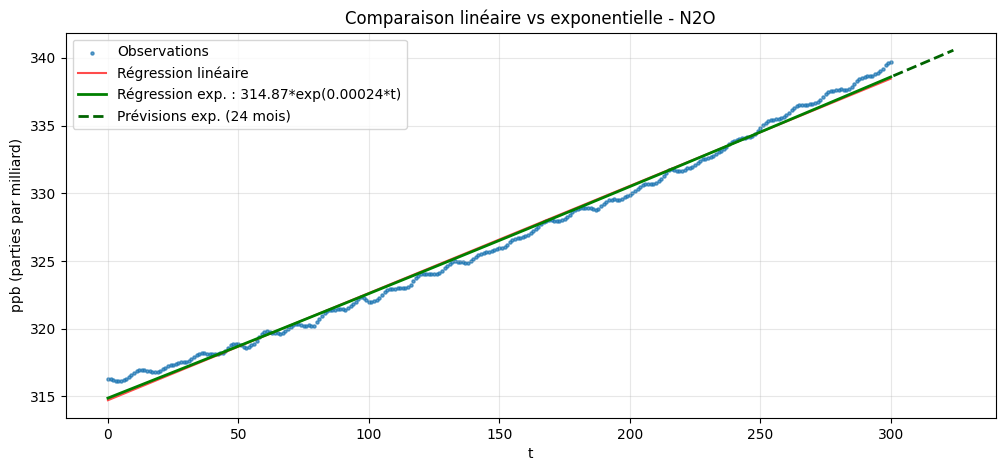


Le modèle exponentiel est plus pertinent (erreur moyenne plus faible).


In [9]:
r_log, A, B, future_t_exp, forecast_exp, rmse_lin, rmse_exp, y_hat_exp = exp_regression_analysis(t, y)

print(f"Coefficient de corrélation (sur log) : {r_log:.6f}")
print(f"Équation : x_t = {A:.4f} * exp({B:.6f}*t)")
print(f"Erreur moyenne (modèle linéaire) : {rmse_lin:.4f}")
print(f"Erreur moyenne (modèle exponentiel) : {rmse_exp:.4f}")

plt.figure(figsize=(12, 5))
plt.scatter(t, y, s=5, alpha=0.7, label='Observations')
plt.plot(t, model_lin.predict(t.reshape(-1, 1)), color='red', alpha=0.7,
         label='Régression linéaire')
plt.plot(t, y_hat_exp, color='green', linewidth=2,
         label=f'Régression exp. : {A:.2f}*exp({B:.5f}*t)')
plt.plot(future_t_exp, forecast_exp, '--', color='darkgreen', linewidth=2, label='Prévisions exp. (24 mois)')
plt.title(f'Comparaison linéaire vs exponentielle - {gas}')
plt.xlabel('t'); plt.ylabel(units[gas]); plt.legend(); plt.grid(alpha=0.3)
plt.show()

better = 'exponentiel' if rmse_exp < rmse_lin else 'linéaire'
print(f"\nLe modèle {better} est plus pertinent (erreur moyenne plus faible).")


## Questions 7 et 8 - SF6


--- Régression linéaire ---
Coefficient de corrélation r = 0.994830
Équation : x_t = 0.024688*t + 3.4559

--- Régression exponentielle ---
Équation : x_t = 4.1237 * exp(0.003325*t)
Erreur moyenne linéaire : 0.2495 | Erreur moyenne exponentielle : 0.1266


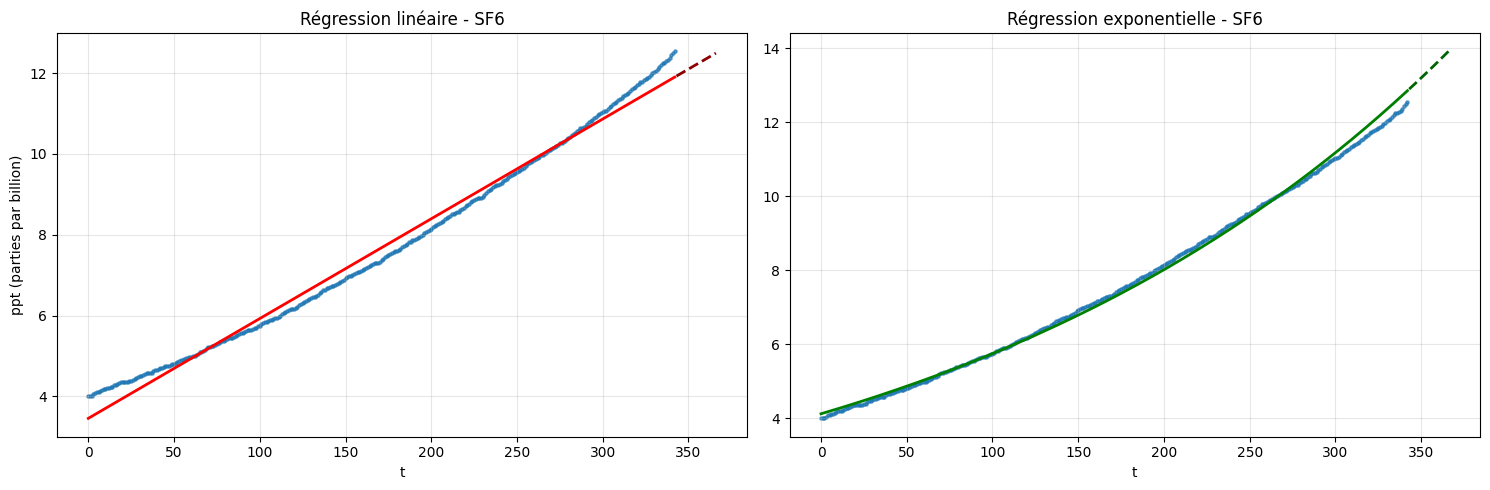


Le modèle exponentiel est plus pertinent pour le SF6.


In [10]:
gas = 'SF6'
df = dataframes[gas]
t = df.index.values.astype(float)
y = df['average'].values

# Régression linéaire
r, a, b, model_lin, future_t, forecast_lin = linear_regression_analysis(t, y)
print(f"--- Régression linéaire ---")
print(f"Coefficient de corrélation r = {r:.6f}")
print(f"Équation : x_t = {a:.6f}*t + {b:.4f}")

# Régression exponentielle
r_log, A, B, future_t_exp, forecast_exp, rmse_lin, rmse_exp, y_hat_exp = exp_regression_analysis(t, y)
print(f"\n--- Régression exponentielle ---")
print(f"Équation : x_t = {A:.4f} * exp({B:.6f}*t)")
print(f"Erreur moyenne linéaire : {rmse_lin:.4f} | Erreur moyenne exponentielle : {rmse_exp:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(t, y, s=5, alpha=0.7)
axes[0].plot(t, model_lin.predict(t.reshape(-1, 1)), color='red', linewidth=2)
axes[0].plot(future_t, forecast_lin, '--', color='darkred', linewidth=2)
axes[0].set_title(f'Régression linéaire - {gas}')
axes[0].set_xlabel('t'); axes[0].set_ylabel(units[gas]); axes[0].grid(alpha=0.3)

axes[1].scatter(t, y, s=5, alpha=0.7)
axes[1].plot(t, y_hat_exp, color='green', linewidth=2)
axes[1].plot(future_t_exp, forecast_exp, '--', color='darkgreen', linewidth=2)
axes[1].set_title(f'Régression exponentielle - {gas}')
axes[1].set_xlabel('t'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

better = 'exponentiel' if rmse_exp < rmse_lin else 'linéaire'
print(f"\nLe modèle {better} est plus pertinent pour le SF6.")


### Interprétation - SF6

Le SF6 augmente de plus en plus vite : la hausse s'accélère au fil des années. Le modèle **exponentiel** colle en général mieux aux données (erreur moyenne plus faible) que la droite, car l'augmentation n'est pas toujours du même montant, mais grossit en proportion. Pour le N2O, les deux modèles se ressemblent davantage ; l'exponentiel peut tout de même être un peu meilleur si la hausse récente s'accélère.


## Questions 9 et 10 - Analyse annuelle : CO2

On calcule une **moyenne par année** à partir des mesures mensuelles. Cela permet d'observer la tendance sur le long terme, sans l'effet des mois.


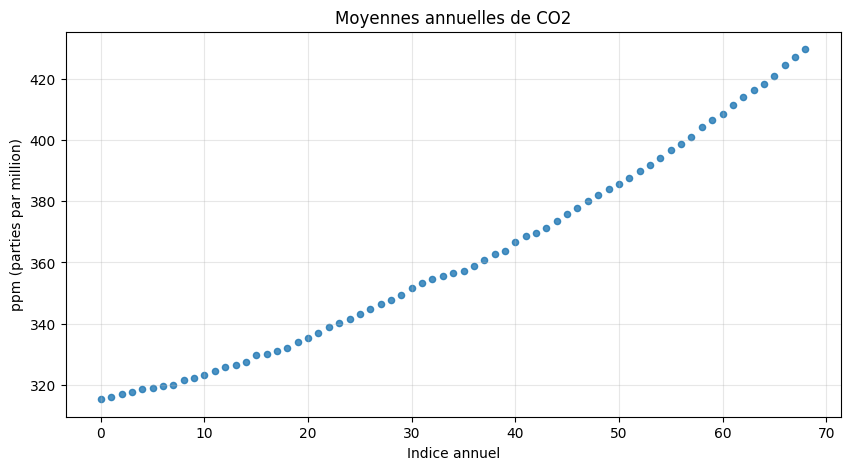

--- Régression linéaire annuelle ---
r = 0.989491
Équation : x_t = 1.6730*t + 304.69

--- Régression exponentielle annuelle ---
Équation : x_t = 307.95 * exp(0.00460*t)
Erreur moyenne linéaire : 4.8692 | Erreur moyenne exponentielle : 3.5487


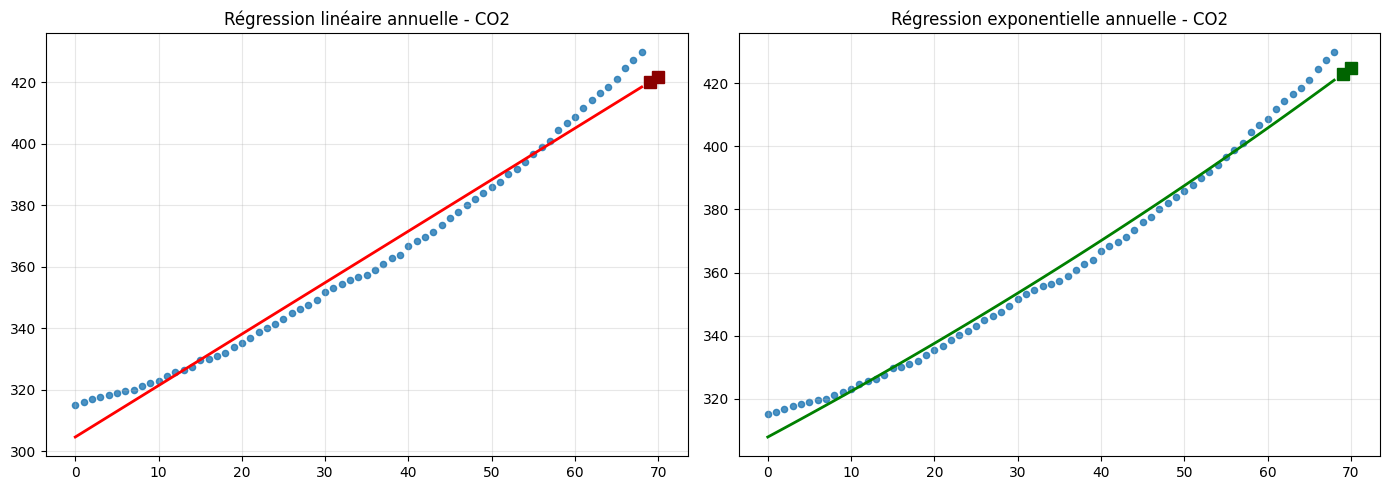


Prévisions linéaires pour 2027 et 2028 : [420.13 421.81]
Prévisions exponentielles : [422.87 424.82]


In [11]:
gas = 'CO2'
df_annual = annual_aggregate(dataframes_raw[gas])
t_ann = np.arange(len(df_annual), dtype=float)
y_ann = df_annual['average'].values
years = df_annual['year'].values

# Nuage de points
plt.figure(figsize=(10, 5))
plt.scatter(t_ann, y_ann, s=20, alpha=0.8)
plt.title(f'Moyennes annuelles de {gas}')
plt.xlabel('Indice annuel'); plt.ylabel(units[gas]); plt.grid(alpha=0.3)
plt.show()

# Régression linéaire
r_lin, a_lin, b_lin, model_ann_lin, future_t_ann, forecast_ann_lin = linear_regression_analysis(
    t_ann, y_ann, n_forecast=2
)
print(f"--- Régression linéaire annuelle ---")
print(f"r = {r_lin:.6f}")
print(f"Équation : x_t = {a_lin:.4f}*t + {b_lin:.2f}")

# Régression exponentielle
r_log, A, B, future_t_exp, forecast_ann_exp, rmse_lin, rmse_exp, y_hat = exp_regression_analysis(
    t_ann, y_ann, n_forecast=2
)
print(f"\n--- Régression exponentielle annuelle ---")
print(f"Équation : x_t = {A:.2f} * exp({B:.5f}*t)")
print(f"Erreur moyenne linéaire : {rmse_lin:.4f} | Erreur moyenne exponentielle : {rmse_exp:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(t_ann, y_ann, s=20, alpha=0.8)
axes[0].plot(t_ann, model_ann_lin.predict(t_ann.reshape(-1, 1)), color='red', linewidth=2)
future_years_idx = np.arange(len(t_ann), len(t_ann) + 2)
axes[0].plot(future_years_idx, forecast_ann_lin, 's--', color='darkred', markersize=8, label='Prévisions')
axes[0].set_title(f'Régression linéaire annuelle - {gas}'); axes[0].grid(alpha=0.3)

axes[1].scatter(t_ann, y_ann, s=20, alpha=0.8)
axes[1].plot(t_ann, y_hat, color='green', linewidth=2)
axes[1].plot(future_years_idx, forecast_ann_exp, 's--', color='darkgreen', markersize=8, label='Prévisions')
axes[1].set_title(f'Régression exponentielle annuelle - {gas}'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

future_years = [years[-1] + i for i in range(1, 3)]
print(f"\nPrévisions linéaires pour {future_years[0]} et {future_years[1]} : {forecast_ann_lin.round(2)}")
print(f"Prévisions exponentielles : {forecast_ann_exp.round(2)}")


## Questions 9 et 10 - Analyse annuelle : CH4


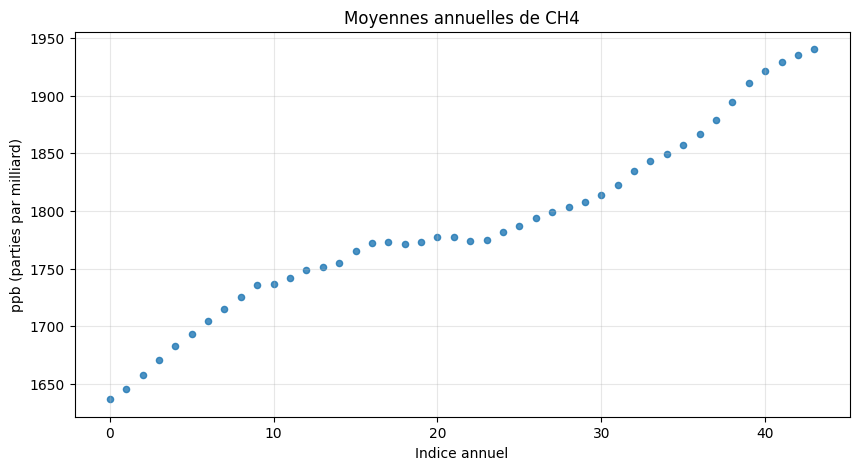

Régression linéaire : r = 0.975563, x_t = 5.9581*t + 1658.93
Régression exponentielle : x_t = 1662.00*exp(0.00333*t)
Erreur moyenne linéaire : 17.0399 | Erreur moyenne exponentielle : 16.6748


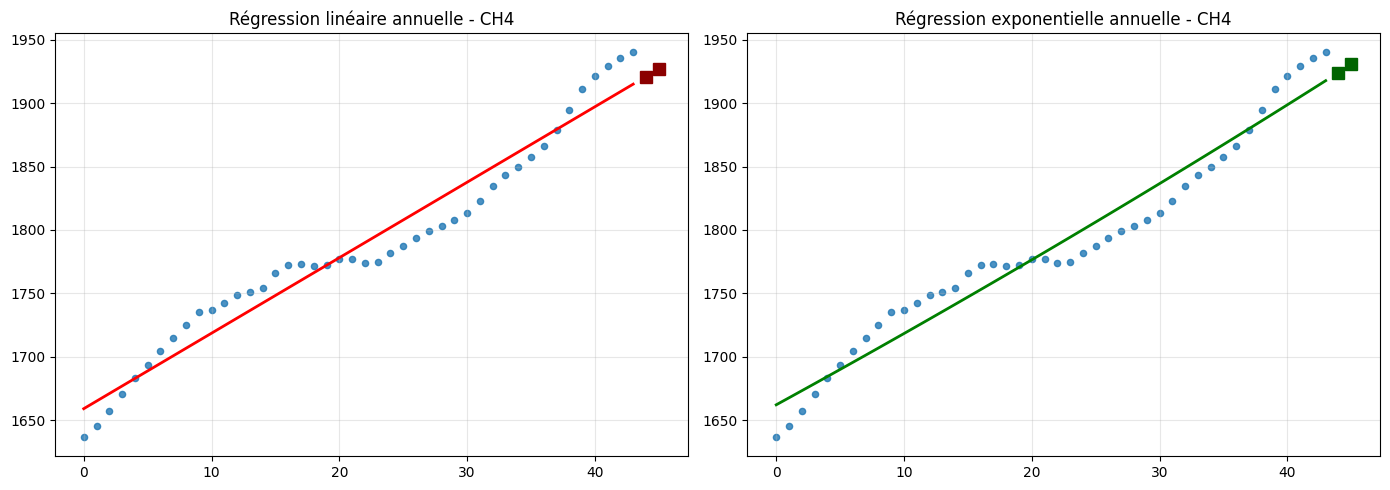

Prévisions linéaires [np.int64(2027), np.int64(2028)] : [1921.08 1927.04]
Prévisions exponentielles : [1924.26 1930.68]
Modèle plus pertinent : exponentiel


In [12]:
gas = 'CH4'
df_annual = annual_aggregate(dataframes_raw[gas])
t_ann = np.arange(len(df_annual), dtype=float)
y_ann = df_annual['average'].values
years = df_annual['year'].values

plt.figure(figsize=(10, 5))
plt.scatter(t_ann, y_ann, s=20, alpha=0.8)
plt.title(f'Moyennes annuelles de {gas}')
plt.xlabel('Indice annuel'); plt.ylabel(units[gas]); plt.grid(alpha=0.3)
plt.show()

r_lin, a_lin, b_lin, model_ann_lin, future_t_ann, forecast_ann_lin = linear_regression_analysis(
    t_ann, y_ann, n_forecast=2
)
r_log, A, B, future_t_exp, forecast_ann_exp, rmse_lin, rmse_exp, y_hat = exp_regression_analysis(
    t_ann, y_ann, n_forecast=2
)

print(f"Régression linéaire : r = {r_lin:.6f}, x_t = {a_lin:.4f}*t + {b_lin:.2f}")
print(f"Régression exponentielle : x_t = {A:.2f}*exp({B:.5f}*t)")
print(f"Erreur moyenne linéaire : {rmse_lin:.4f} | Erreur moyenne exponentielle : {rmse_exp:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(t_ann, y_ann, s=20, alpha=0.8)
axes[0].plot(t_ann, model_ann_lin.predict(t_ann.reshape(-1, 1)), color='red', linewidth=2)
future_years_idx = np.arange(len(t_ann), len(t_ann) + 2)
axes[0].plot(future_years_idx, forecast_ann_lin, 's--', color='darkred', markersize=8)
axes[0].set_title(f'Régression linéaire annuelle - {gas}'); axes[0].grid(alpha=0.3)

axes[1].scatter(t_ann, y_ann, s=20, alpha=0.8)
axes[1].plot(t_ann, y_hat, color='green', linewidth=2)
axes[1].plot(future_years_idx, forecast_ann_exp, 's--', color='darkgreen', markersize=8)
axes[1].set_title(f'Régression exponentielle annuelle - {gas}'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

future_years = [years[-1] + i for i in range(1, 3)]
print(f"Prévisions linéaires {future_years} : {forecast_ann_lin.round(2)}")
print(f"Prévisions exponentielles : {forecast_ann_exp.round(2)}")
better = 'exponentiel' if rmse_exp < rmse_lin else 'linéaire'
print(f"Modèle plus pertinent : {better}")


## Conclusion

Ce mini-projet nous a permis d'étudier quatre gaz mesurés dans l'atmosphère.

**Ce que l'on observe** : le CO2 et le CH4 varient selon les mois ; le N2O et le SF6 augmentent surtout de façon régulière dans le temps.

**Ce que l'on a fait** : pour le CO2 et le CH4, on a séparé la tendance générale et l'effet des mois (questions 5 et 6). Pour le N2O et le SF6, on a tracé une droite ou une courbe exponentielle (questions 7 et 8). Enfin, on a refait l'étude sur des moyennes annuelles (questions 9 et 10).

**Quel modèle choisir ?** : le modèle additif convient bien au CO2 et au CH4. Pour le SF6, la courbe exponentielle est souvent meilleure que la droite. Sur des données annuelles, la droite suffit souvent pour le CO2.

**Limites** : nos prévisions supposent que le futur ressemblera au passé (mêmes variations selon les mois, même type de hausse). Elles ne prévoient pas un changement soudain lié, par exemple, à de nouvelles règles ou à un événement exceptionnel.
